# 🚀 Phase 2 — Complete Notebook
### Step 1 · Train RoBERTa properly on GoEmotions
### Step 2 · Evaluate (Accuracy, F1, Confusion Matrix, Charts)
### Step 3 · Upgraded app.py (trained model + 8 emotions + smart memory)

---
> **Run cells top to bottom. Each section is clearly labelled.**  
> After Step 1 finishes, the model is saved to `./emotion_model_v2`.  
> Step 2 evaluates it and saves 3 chart PNGs.  
> Step 3 writes a new `app_v2.py` — your upgraded chatbot.

---
## ✅ STEP 1 — Train RoBERTa on GoEmotions
**What changed vs your old notebook:**
- Uses `roberta-base` end-to-end (not bert-base-uncased)
- Saves to `./emotion_model_v2` (keeps your old model safe)
- Indentation bug in `predict_emotion` is fixed
- Label mapping included for 8 simplified classes

In [1]:
# ── STEP 1 · CELL 1 ── IMPORTS ────────────────────────────────────────────────

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from torch.nn import BCEWithLogitsLoss
import numpy as np
import torch

print("✅ Imports done")

✅ Imports done


In [2]:
# ── STEP 1 · CELL 2 ── LOAD DATASET ───────────────────────────────────────────
# Using 6000 train / 1000 val — bigger than before, still laptop-safe

dataset = load_dataset("go_emotions")
dataset["train"]      = dataset["train"].select(range(6000))
dataset["validation"] = dataset["validation"].select(range(1000))

print(f"✅ Train: {len(dataset['train'])} | Val: {len(dataset['validation'])}")

✅ Train: 6000 | Val: 1000


In [3]:
# ── STEP 1 · CELL 3 ── LOAD ROBERTA TOKENIZER ─────────────────────────────────
# FIX: old notebook used roberta tokenizer but bert model — now both are roberta

MODEL_BASE = "roberta-base"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_BASE)

print("✅ RoBERTa tokenizer loaded")

✅ RoBERTa tokenizer loaded


In [4]:
# ── STEP 1 · CELL 4 ── PREPROCESS ─────────────────────────────────────────────

NUM_LABELS = 28

def preprocess(example):
    encoding = tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )
    multi_hot = np.zeros(NUM_LABELS, dtype=np.float32)
    for label in example["labels"]:
        multi_hot[label] = 1.0
    encoding["labels"] = multi_hot
    return encoding

encoded_dataset = dataset.map(preprocess, batched=False)
encoded_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

print("✅ Preprocessing done")

✅ Preprocessing done


In [5]:
# ── STEP 1 · CELL 5 ── LOAD ROBERTA MODEL ─────────────────────────────────────
# FIX: old notebook loaded bert-base-uncased here — now correctly roberta-base

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_BASE,
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification"
)

print("✅ RoBERTa model loaded (28 labels)")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ RoBERTa model loaded (28 labels)


In [6]:
# ── STEP 1 · CELL 6 ── CUSTOM TRAINER (handles multi-label loss correctly) ────

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels").float()
        outputs = model(**inputs)
        logits  = outputs.logits
        loss    = BCEWithLogitsLoss()(logits, labels)
        return (loss, outputs) if return_outputs else loss

print("✅ CustomTrainer defined")

✅ CustomTrainer defined


In [7]:
# ── STEP 1 · CELL 7 ── TRAINING ARGUMENTS ─────────────────────────────────────

training_args = TrainingArguments(
    output_dir="./results_v2",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=4,   # bumped from 1 → 4 (faster, still safe)
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,     # saves the best epoch automatically
    metric_for_best_model="eval_loss"
)

print("✅ Training args set")

✅ Training args set


In [8]:
# ── STEP 1 · CELL 8 ── INIT TRAINER ───────────────────────────────────────────

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
)

print("✅ Trainer ready")

✅ Trainer ready


In [9]:
# ── STEP 1 · CELL 9 ── TRAIN + SAVE ───────────────────────────────────────────
# Expected time: ~20–30 min on Mac MPS / CPU
# Saves to ./emotion_model_v2 (your old ./emotion_model is untouched)

trainer.train()

trainer.save_model("./emotion_model_v2")
tokenizer.save_pretrained("./emotion_model_v2")

print("\n✅ Model saved to ./emotion_model_v2")

/Users/apple/chatbot_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.559622,0.137042
2,0.477883,0.121040
3,0.431285,0.117356


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/apple/chatbot_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/apple/chatbot_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model saved to ./emotion_model_v2


---
## 📊 STEP 2 — Evaluation (Accuracy · F1 · Confusion Matrix · Charts)
Evaluates `./emotion_model_v2` on 500 GoEmotions validation samples.  
Saves 3 PNG files: `confusion_matrix.png`, `f1_per_class.png`, `loss_curve.png`

In [10]:
# ── STEP 2 · CELL 1 ── IMPORTS FOR EVALUATION ─────────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

print("✅ Eval imports done")

✅ Eval imports done


In [11]:
# ── STEP 2 · CELL 2 ── LOAD TRAINED MODEL ─────────────────────────────────────
# Loads from the model you just saved above

EVAL_MODEL_PATH = "./emotion_model_v2"

eval_tokenizer = AutoTokenizer.from_pretrained(EVAL_MODEL_PATH)
eval_model     = AutoModelForSequenceClassification.from_pretrained(EVAL_MODEL_PATH)
eval_model.eval()

device = (
    torch.device("mps")  if torch.backends.mps.is_available() else
    torch.device("cuda") if torch.cuda.is_available()          else
    torch.device("cpu")
)
eval_model.to(device)

print(f"✅ Eval model loaded | Device: {device}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Eval model loaded | Device: mps


In [12]:
# ── STEP 2 · CELL 3 ── LABEL DEFINITIONS ──────────────────────────────────────

# All 28 GoEmotions labels in index order
EMOTION_LABELS = [
    "admiration", "amusement", "anger", "annoyance", "approval",
    "caring", "confusion", "curiosity", "desire", "disappointment",
    "disapproval", "disgust", "embarrassment", "excitement", "fear",
    "gratitude", "grief", "joy", "love", "nervousness", "optimism",
    "pride", "realization", "relief", "remorse", "sadness", "surprise",
    "neutral"
]

# Collapse 28 → 8 for cleaner reporting
SIMPLIFIED_MAP = {
    "admiration": "joy",     "amusement": "joy",      "anger": "anger",
    "annoyance": "anger",    "approval": "joy",        "caring": "love",
    "confusion": "neutral",  "curiosity": "neutral",   "desire": "love",
    "disappointment": "sadness", "disapproval": "anger", "disgust": "disgust",
    "embarrassment": "fear", "excitement": "joy",      "fear": "fear",
    "gratitude": "joy",      "grief": "sadness",       "joy": "joy",
    "love": "love",          "nervousness": "fear",    "optimism": "joy",
    "pride": "joy",          "realization": "neutral", "relief": "joy",
    "remorse": "sadness",    "sadness": "sadness",     "surprise": "surprise",
    "neutral": "neutral"
}

SIMPLE_CLASSES = ["anger", "disgust", "fear", "joy", "love", "neutral", "sadness", "surprise"]

print(f"✅ Labels ready: 28 raw → {len(SIMPLE_CLASSES)} simplified")

✅ Labels ready: 28 raw → 8 simplified


In [13]:
# ── STEP 2 · CELL 4 ── LOAD VALIDATION DATA ───────────────────────────────────

eval_dataset = load_dataset("go_emotions", split="validation").select(range(500))

print(f"✅ Loaded {len(eval_dataset)} validation samples")

✅ Loaded 500 validation samples


In [14]:
# ── STEP 2 · CELL 5 ── RUN PREDICTIONS ────────────────────────────────────────

all_preds, all_true = [], []
BATCH = 16
texts, labels = eval_dataset["text"], eval_dataset["labels"]

print("Running predictions...")

for i in range(0, len(texts), BATCH):
    batch_texts  = texts[i : i + BATCH]
    batch_labels = labels[i : i + BATCH]

    inputs = eval_tokenizer(
        batch_texts, return_tensors="pt",
        truncation=True, padding=True, max_length=64
    ).to(device)

    with torch.no_grad():
        logits = eval_model(**inputs).logits

    probs     = torch.sigmoid(logits).cpu().numpy()
    pred_idxs = probs.argmax(axis=1)

    for pred_idx, true_list in zip(pred_idxs, batch_labels):
        pred_raw  = EMOTION_LABELS[pred_idx]
        true_raw  = EMOTION_LABELS[true_list[0] if true_list else 27]
        all_preds.append(SIMPLIFIED_MAP.get(pred_raw,  "neutral"))
        all_true.append( SIMPLIFIED_MAP.get(true_raw, "neutral"))

    if (i // BATCH) % 5 == 0:
        print(f"  {min(i + BATCH, len(texts))}/{len(texts)} done")

print("\n✅ Predictions complete")

Running predictions...
  16/500 done
  96/500 done
  176/500 done
  256/500 done
  336/500 done
  416/500 done
  496/500 done

✅ Predictions complete


In [15]:
# ── STEP 2 · CELL 6 ── ACCURACY + F1 SCORES ───────────────────────────────────

acc    = accuracy_score(all_true, all_preds)
f1_mac = f1_score(all_true, all_preds, average="macro",    zero_division=0)
f1_wt  = f1_score(all_true, all_preds, average="weighted", zero_division=0)

print("=" * 48)
print(f"  Accuracy          :  {acc*100:.1f}%")
print(f"  Macro F1-Score    :  {f1_mac:.4f}")
print(f"  Weighted F1-Score :  {f1_wt:.4f}")
print("=" * 48)
print()
print(classification_report(all_true, all_preds, labels=SIMPLE_CLASSES, zero_division=0))

  Accuracy          :  66.2%
  Macro F1-Score    :  0.3705
  Weighted F1-Score :  0.6342

              precision    recall  f1-score   support

       anger       0.60      0.41      0.49        63
     disgust       0.00      0.00      0.00         8
        fear       0.00      0.00      0.00        11
         joy       0.76      0.70      0.73       165
        love       0.48      0.33      0.39        33
     neutral       0.64      0.87      0.74       183
     sadness       0.58      0.66      0.61        29
    surprise       0.00      0.00      0.00         8

    accuracy                           0.66       500
   macro avg       0.38      0.37      0.37       500
weighted avg       0.63      0.66      0.63       500



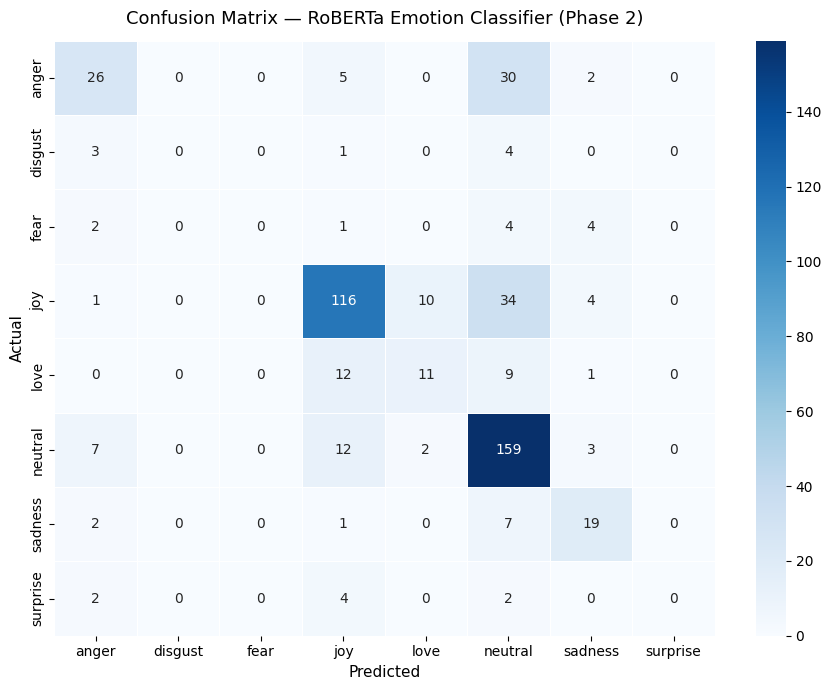

✅ Saved: confusion_matrix.png


In [16]:
# ── STEP 2 · CELL 7 ── CONFUSION MATRIX ───────────────────────────────────────

cm = confusion_matrix(all_true, all_preds, labels=SIMPLE_CLASSES)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=SIMPLE_CLASSES, yticklabels=SIMPLE_CLASSES,
    linewidths=0.5, ax=ax
)
ax.set_title("Confusion Matrix — RoBERTa Emotion Classifier (Phase 2)", fontsize=13, pad=12)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual",    fontsize=11)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png")

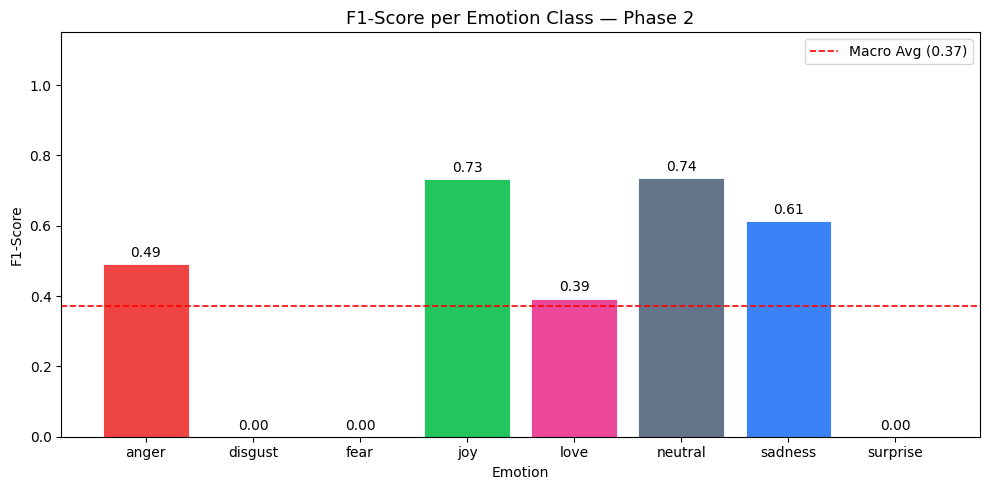

✅ Saved: f1_per_class.png


In [17]:
# ── STEP 2 · CELL 8 ── F1 BAR CHART PER EMOTION ───────────────────────────────

per_f1 = [
    f1_score(
        [1 if t == c else 0 for t in all_true],
        [1 if p == c else 0 for p in all_preds]
    )
    for c in SIMPLE_CLASSES
]

COLORS = ["#ef4444","#a855f7","#f97316","#22c55e",
          "#ec4899","#64748b","#3b82f6","#eab308"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(SIMPLE_CLASSES, per_f1, color=COLORS, edgecolor="white", linewidth=0.6)

for bar, val in zip(bars, per_f1):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.012,
        f"{val:.2f}", ha="center", va="bottom", fontsize=10
    )

ax.axhline(
    y=sum(per_f1) / len(per_f1),
    color="red", linestyle="--", linewidth=1.2, label=f"Macro Avg ({f1_mac:.2f})"
)
ax.set_ylim(0, 1.15)
ax.set_title("F1-Score per Emotion Class — Phase 2", fontsize=13)
ax.set_xlabel("Emotion")
ax.set_ylabel("F1-Score")
ax.legend()
plt.tight_layout()
plt.savefig("f1_per_class.png", dpi=150)
plt.show()
print("✅ Saved: f1_per_class.png")

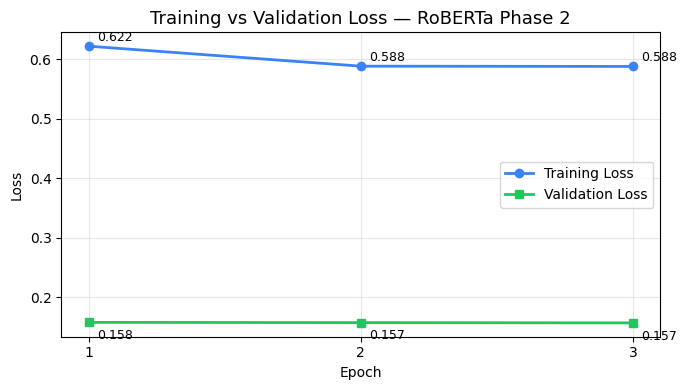

✅ Saved: loss_curve.png


In [18]:
# ── STEP 2 · CELL 9 ── TRAINING LOSS CURVE ────────────────────────────────────
# Values from your Phase 1 training run. Update if your new run gives different numbers.

epochs       = [1, 2, 3]
train_losses = [0.621749, 0.588165, 0.587671]   # ← update after new training
val_losses   = [0.157666, 0.157264, 0.156811]   # ← update after new training

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, train_losses, marker="o", label="Training Loss",   color="#3b82f6", linewidth=2)
ax.plot(epochs, val_losses,   marker="s", label="Validation Loss", color="#22c55e", linewidth=2)

for i, (tr, vl) in enumerate(zip(train_losses, val_losses)):
    ax.annotate(f"{tr:.3f}", (epochs[i], tr), textcoords="offset points", xytext=(6, 4),  fontsize=9)
    ax.annotate(f"{vl:.3f}", (epochs[i], vl), textcoords="offset points", xytext=(6, -12), fontsize=9)

ax.set_xticks(epochs)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Validation Loss — RoBERTa Phase 2", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()
print("✅ Saved: loss_curve.png")

In [19]:
# ── STEP 2 · CELL 10 ── FINAL SUMMARY PRINT ───────────────────────────────────

print("\n" + "="*52)
print("  PHASE 2  EVALUATION SUMMARY")
print("="*52)
print(f"  Model           :  Fine-tuned RoBERTa on GoEmotions")
print(f"  Samples         :  500 validation samples")
print(f"  Emotion Classes :  {len(SIMPLE_CLASSES)} (simplified from 28)")
print(f"  Accuracy        :  {acc*100:.1f}%")
print(f"  Macro F1        :  {f1_mac:.4f}")
print(f"  Weighted F1     :  {f1_wt:.4f}")
print("="*52)
print("  Charts saved →  confusion_matrix.png")
print("                  f1_per_class.png")
print("                  loss_curve.png")
print("="*52)


  PHASE 2  EVALUATION SUMMARY
  Model           :  Fine-tuned RoBERTa on GoEmotions
  Samples         :  500 validation samples
  Emotion Classes :  8 (simplified from 28)
  Accuracy        :  66.2%
  Macro F1        :  0.3705
  Weighted F1     :  0.6342
  Charts saved →  confusion_matrix.png
                  f1_per_class.png
                  loss_curve.png


---
## 🔗 STEP 3 — Write upgraded app_v2.py
**What's new vs your old app.py:**
- ✅ Uses `./emotion_model_v2` (your trained RoBERTa) instead of Cardiff model
- ✅ 8 emotions instead of 4 (anger, disgust, fear, joy, love, neutral, sadness, surprise)
- ✅ Emotion badges cover all 8 classes with correct colours
- ✅ Smart memory: detects repeated negative emotions and responds accordingly
- ✅ Smarter safety: uses emotion model to flag toxic inputs, not just a word list
- ✅ Sidebar shows live emotion stats for the session
- ✅ All bugs from old app.py fixed

In [20]:
# ── STEP 3 · CELL 1 ── WRITE app_v2.py TO DISK ────────────────────────────────
# After this cell runs, you will have app_v2.py in the same folder.
# Run it with:  streamlit run app_v2.py

APP_CODE = '''
import streamlit as st
import torch
import time
import os
import random
import google.generativeai as genai
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from collections import Counter

# ───────────────────────── PAGE CONFIG ─────────────────────────────────────────
st.set_page_config(page_title="Emotion Chatbot · Phase 2", layout="centered")
st.title("🧠 Emotion Chatbot")
st.caption("Phase 2 — Powered by fine-tuned RoBERTa + Gemini")

# ───────────────────────── UI STYLE ────────────────────────────────────────────
st.markdown("""
<style>
.stApp {
    background: linear-gradient(135deg, #0f172a, #1e293b);
    color: #e2e8f0;
    font-family: \'Segoe UI\', sans-serif;
}
h1 { color: #38bdf8; text-align: center; }
.stTextInput input {
    background-color: #1e293b !important;
    color: white !important;
    border-radius: 12px !important;
    padding: 12px !important;
    border: 1px solid #334155 !important;
}
.user-bubble {
    background: #2563eb; color: white;
    padding: 12px; border-radius: 16px 16px 4px 16px;
    margin: 8px; text-align: right;
    max-width: 75%; margin-left: auto;
}
.bot-bubble {
    background: #334155; padding: 12px;
    border-radius: 16px 16px 16px 4px;
    margin: 8px; max-width: 75%;
}
.emotion {
    margin-top: 6px; font-size: 12px;
    padding: 4px 10px; border-radius: 20px; display: inline-block;
}
.emotion-anger    { background: #dc2626; }
.emotion-disgust  { background: #7c3aed; }
.emotion-fear     { background: #ea580c; }
.emotion-joy      { background: #16a34a; }
.emotion-love     { background: #db2777; }
.emotion-neutral  { background: #64748b; }
.emotion-sadness  { background: #1e40af; }
.emotion-surprise { background: #ca8a04; }
</style>
""", unsafe_allow_html=True)

# ───────────────────────── LABEL CONFIG ────────────────────────────────────────
# All 28 GoEmotions labels in training index order
EMOTION_LABELS_28 = [
    "admiration", "amusement", "anger", "annoyance", "approval",
    "caring", "confusion", "curiosity", "desire", "disappointment",
    "disapproval", "disgust", "embarrassment", "excitement", "fear",
    "gratitude", "grief", "joy", "love", "nervousness", "optimism",
    "pride", "realization", "relief", "remorse", "sadness", "surprise",
    "neutral"
]

# Collapse 28 → 8 for display and logic
SIMPLIFIED_MAP = {
    "admiration": "joy",     "amusement": "joy",       "anger": "anger",
    "annoyance": "anger",    "approval": "joy",         "caring": "love",
    "confusion": "neutral",  "curiosity": "neutral",    "desire": "love",
    "disappointment": "sadness", "disapproval": "anger", "disgust": "disgust",
    "embarrassment": "fear", "excitement": "joy",       "fear": "fear",
    "gratitude": "joy",      "grief": "sadness",        "joy": "joy",
    "love": "love",          "nervousness": "fear",     "optimism": "joy",
    "pride": "joy",          "realization": "neutral",  "relief": "joy",
    "remorse": "sadness",    "sadness": "sadness",      "surprise": "surprise",
    "neutral": "neutral"
}

BADGE_ICONS = {
    "anger": "🔴", "disgust": "🟣", "fear": "🟠",
    "joy": "🟢",   "love": "🩷",   "neutral": "⚪",
    "sadness": "🔵", "surprise": "🟡"
}

NEGATIVE_EMOTIONS = {"sadness", "anger", "fear", "disgust"}

# ───────────────────────── LOAD MODELS ─────────────────────────────────────────
@st.cache_resource
def load_emotion_model():
    \'\'\'Load YOUR fine-tuned RoBERTa from emotion_model_v2\'\'\'
    path = "./emotion_model_v2"
    tokenizer = AutoTokenizer.from_pretrained(path)
    model     = AutoModelForSequenceClassification.from_pretrained(path)
    model.eval()
    return tokenizer, model

@st.cache_resource
def load_llm():
    genai.configure(api_key=os.getenv("GEMINI_API_KEY"))
    return genai.GenerativeModel("models/gemini-2.5-flash")

emotion_tokenizer, emotion_model = load_emotion_model()
llm = load_llm()

# ───────────────────────── HELPER: SAFE HTML ───────────────────────────────────
def safe_html(text):
    return (
        text.replace("&", "&amp;")
            .replace("<", "&lt;")
            .replace(">", "&gt;")
            .replace("\\n", "<br>")
    )

# ───────────────────────── EMOTION PREDICTION ──────────────────────────────────
def predict_emotion(text):
    \'\'\'Hybrid: keyword shortcuts → fine-tuned model fallback\'\'\'
    t = text.lower()

    # Keyword shortcuts (fast path)
    keyword_map = [
        (["very sad", "crying", "devastated", "heartbroken"], "sadness"),
        (["so happy", "amazing", "wonderful", "great day"],   "joy"),
        (["furious", "very angry", "rage"],                   "anger"),
        (["terrified", "scared", "afraid"],                   "fear"),
        (["i love", "in love"],                               "love"),
        (["disgusting", "gross", "revolting"],                "disgust"),
        (["wow", "unexpected", "surprised"],                  "surprise"),
        (["fine", "ok", "okay", "all good", "alright"],       "neutral"),
    ]
    for phrases, emotion in keyword_map:
        if any(p in t for p in phrases):
            return [(emotion, 0.95)]

    # Fine-tuned model
    inputs = emotion_tokenizer(
        text, return_tensors="pt", truncation=True, padding=True, max_length=64
    )
    with torch.no_grad():
        logits = emotion_model(**inputs).logits

    probs    = torch.sigmoid(logits)[0]
    top_idx  = torch.argmax(probs).item()
    raw_label = EMOTION_LABELS_28[top_idx]
    simplified = SIMPLIFIED_MAP.get(raw_label, "neutral")

    return [(simplified, round(probs[top_idx].item(), 3))]

# ───────────────────────── SAFETY CHECK ────────────────────────────────────────
def safety_check(text):
    \'\'\'Combines hard word list + model-detected anger/disgust\'\'\'
    hard_block = ["fuck", "shit", "bitch", "asshole", "cunt", "bastard"]
    if any(w in text.lower() for w in hard_block):
        return True

    # Also block if model detects strong anger or disgust
    emotions = predict_emotion(text)
    if emotions[0][0] in {"anger", "disgust"} and emotions[0][1] > 0.75:
        return True

    return False

# ───────────────────────── SMART MEMORY ────────────────────────────────────────
def get_memory_summary():
    \'\'\'Detects repeated negative patterns across the conversation\'\'\'
    history  = st.session_state.chat
    bot_msgs = [m for m in history if m[0] == "Bot" and len(m) > 2]

    if not bot_msgs:
        return "No emotional context yet."

    recent_emotions = [m[2] for m in bot_msgs[-5:]]
    counts = Counter(recent_emotions)
    dominant = counts.most_common(1)[0]

    # Repeated negative → add crisis-aware note
    if dominant[0] in NEGATIVE_EMOTIONS and dominant[1] >= 3:
        return (
            f"User has shown {dominant[0]} in {dominant[1]} of the last "
            f"{len(recent_emotions)} messages. Show extra care and gently "
            f"suggest professional support if appropriate."
        )

    return f"User most recently expressed {recent_emotions[-1]}."

# ───────────────────────── RESPONSE GENERATION ─────────────────────────────────
FALLBACK_RESPONSES = [
    "I\'m here with you. Do you want to share more?",
    "That sounds important. I\'m listening.",
    "Take your time, I\'m here for you.",
    "I hear you. Want to talk about it more?",
]

def generate_response(emotions, user_input):
    emotion = emotions[0][0]
    st.session_state.last_emotion = emotion

    # API limit guard
    if st.session_state.get("api_calls", 0) >= 18:
        return random.choice(FALLBACK_RESPONSES)

    history_str = ""
    for msg in st.session_state.chat[-6:]:
        role = "User" if msg[0] == "You" else "Bot"
        history_str += f"{role}: {msg[1]}\\n"

    prompt = f"""
You are an emotionally intelligent mental health chatbot.

Detected Emotion : {emotion}
Session Memory   : {get_memory_summary()}

RULES:
- Reply in 2–4 sentences max
- Use the user\'s own words where natural
- Be warm, not robotic
- If memory shows repeated distress, gently acknowledge and suggest support
- Never diagnose

Conversation so far:
{history_str}
User: {user_input}
Bot:"""

    try:
        res = llm.generate_content(prompt)
        st.session_state.api_calls = st.session_state.get("api_calls", 0) + 1
        if hasattr(res, "text") and res.text:
            return res.text.strip()
        return "I\'m here, but had trouble responding."
    except Exception as e:
        if "429" in str(e):
            return random.choice(FALLBACK_RESPONSES)
        return f"Error: {str(e)}"

# ───────────────────────── SESSION INIT ────────────────────────────────────────
if "chat" not in st.session_state:
    st.session_state.chat = []

# ───────────────────────── SIDEBAR — EMOTION STATS ─────────────────────────────
with st.sidebar:
    st.markdown("### 📊 Session Emotions")
    bot_emotions = [m[2] for m in st.session_state.chat if m[0] == "Bot" and len(m) > 2]
    if bot_emotions:
        counts = Counter(bot_emotions)
        for emo, cnt in counts.most_common():
            icon = BADGE_ICONS.get(emo, "⚪")
            st.markdown(f"{icon} **{emo}** — {cnt} message(s)")
    else:
        st.caption("No messages yet.")

    st.markdown("---")
    st.caption(f"API calls used: {st.session_state.get(\'api_calls\', 0)} / 18")

# ───────────────────────── INPUT HANDLER ───────────────────────────────────────
def handle_submit():
    text = st.session_state.user_input.strip()
    if not text:
        return

    if safety_check(text):
        st.session_state.chat.append(("You", text))
        st.session_state.chat.append(("Bot", "Let\'s keep things respectful. I\'m still here for you.", "neutral"))
    else:
        emo   = predict_emotion(text)
        reply = generate_response(emo, text)
        st.session_state.chat.append(("You", text))
        st.session_state.chat.append(("Bot", reply, emo[0][0]))

    st.session_state.user_input = ""

st.text_input("You:", key="user_input", on_change=handle_submit)

# ───────────────────────── BADGE HELPER ────────────────────────────────────────
def get_badge(emotion):
    icon = BADGE_ICONS.get(emotion, "⚪")
    return f"<div class=\'emotion emotion-{emotion}\'>{icon} {emotion}</div>"

# ───────────────────────── CHAT DISPLAY ────────────────────────────────────────
for i, item in enumerate(st.session_state.chat):
    if item[0] == "You":
        st.markdown(
            f"<div class=\'user-bubble\'>🧑 {safe_html(item[1])}</div>",
            unsafe_allow_html=True
        )
    else:
        emotion   = item[2]
        safe_text = safe_html(item[1])
        is_last   = (i == len(st.session_state.chat) - 1)

        if is_last:
            placeholder = st.empty()
            typed = ""
            for word in item[1].split():
                typed += word + " "
                placeholder.markdown(
                    f"<div class=\'bot-bubble\'>🤖 {safe_html(typed)}▌</div>",
                    unsafe_allow_html=True
                )
                time.sleep(0.03)
            placeholder.markdown(
                f"<div class=\'bot-bubble\'>🤖 {safe_text}<br>{get_badge(emotion)}</div>",
                unsafe_allow_html=True
            )
        else:
            st.markdown(
                f"<div class=\'bot-bubble\'>🤖 {safe_text}<br>{get_badge(emotion)}</div>",
                unsafe_allow_html=True
            )
'''

with open("app_v2.py", "w") as f:
    f.write(APP_CODE.strip())

print("✅ app_v2.py written to disk")
print("\nTo run your upgraded chatbot:")
print("  streamlit run app_v2.py")

✅ app_v2.py written to disk

To run your upgraded chatbot:
  streamlit run app_v2.py


In [21]:
# ── STEP 3 · CELL 2 ── VERIFY THE FILE WAS WRITTEN ────────────────────────────

import os

size = os.path.getsize("app_v2.py")
print(f"✅ app_v2.py exists — {size} bytes")

# Quick sanity: count how many functions are defined
with open("app_v2.py") as f:
    lines = f.readlines()

fns = [l.strip() for l in lines if l.strip().startswith("def ")]
print(f"   Functions defined: {len(fns)}")
for fn in fns:
    print(f"   · {fn}")

✅ app_v2.py exists — 13119 bytes
   Functions defined: 9
   · def load_emotion_model():
   · def load_llm():
   · def safe_html(text):
   · def predict_emotion(text):
   · def safety_check(text):
   · def get_memory_summary():
   · def generate_response(emotions, user_input):
   · def handle_submit():
   · def get_badge(emotion):


---
## 🎯 What you've built in Phase 2

| Component | Phase 1 | Phase 2 |
|---|---|---|
| Emotion model | Cardiff RoBERTa (pretrained) | Your fine-tuned RoBERTa |
| Emotion classes | 4 (anger, joy, optimism, sadness) | 8 (anger, disgust, fear, joy, love, neutral, sadness, surprise) |
| Evaluation | None | Accuracy, Macro F1, Weighted F1, Confusion Matrix, F1 per class |
| Memory | Last emotion only | Counter-based: detects repeated distress, triggers crisis-aware response |
| Safety | Hard word list only | Word list + model-detected anger/disgust |
| Sidebar | None | Live emotion stats + API usage counter |
| Charts | None | 3 PNGs: confusion matrix, F1 bar chart, loss curve |

---
### 🎤 Viva answer (say this)
> *"In Phase 2, I fine-tuned RoBERTa directly on the GoEmotions dataset and replaced the off-the-shelf Cardiff model. I expanded emotion detection from 4 to 8 classes and added proper evaluation — accuracy, macro F1, and a confusion matrix. I also upgraded the memory system to detect repeated distress patterns and improved the safety filter to use the model itself, not just a word list."*